In [60]:
import torch
import numpy as np
from rl.maddpg import MADDPGSharedActorCriticIndependentQmean
from custom_envs.diff_driven.gym_env.centered_paralelenv.env import DiffDriveParallelEnvDone
import pickle
import matplotlib.pyplot as plt
%matplotlib inline




In [61]:
seed=9832
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [62]:
env=DiffDriveParallelEnvDone(v_ang_max=torch.pi/12, num_obstacles=10)


In [63]:
checkpoint_path='C:\\Users\\abzza\\Desktop\\run\\done\\episode_1000_training_state.pkl'

In [64]:
with open(checkpoint_path, "rb") as f:
    state_dict = pickle.load(f)
start_episode = state_dict["episode"]
score_history = state_dict["score_history"]
best_score = state_dict["best_score"]
# replay_buffer.load("replay_buffer.pkl")
episodes_without_improvement = state_dict["episodes_without_improvement"]
total_steps = state_dict['total_steps']
actor_losses=state_dict['actor_losses']
critic_losses=state_dict['critic_losses']

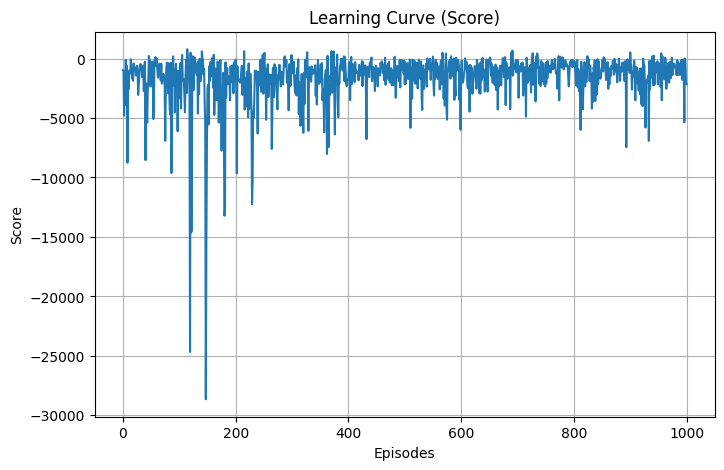

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(score_history)
plt.title('Learning Curve (Score)')
plt.xlabel('Episodes')
plt.ylabel('Score')
plt.grid(True)
plt.show()


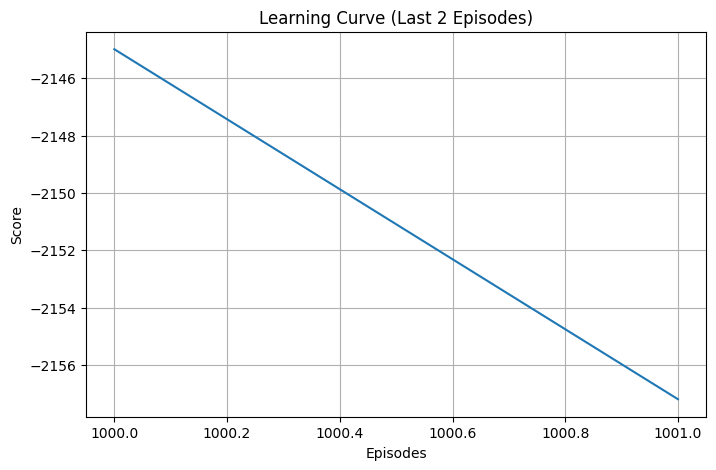

In [66]:
import matplotlib.pyplot as plt

# Let's say score_history is your full list of scores
N = 2  # Window size
windowed_scores = score_history[-N:]
windowed_episodes = list(range(len(score_history) - len(windowed_scores) + 1,
                                len(score_history) + 1))

plt.figure(figsize=(8, 5))
plt.plot(windowed_episodes, windowed_scores)
plt.title(f'Learning Curve (Last {N} Episodes)')
plt.xlabel('Episodes')
plt.ylabel('Score')
plt.grid(True)
plt.show()


('algorithm_flowchart_compact.png', 'algorithm_flowchart_compact.pdf')

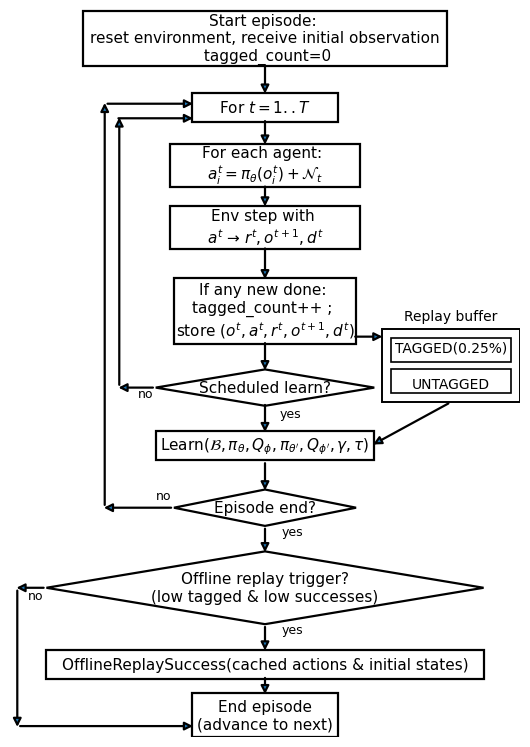

In [245]:
# Flowchart from the provided Algorithm (compact, readable when small)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, FancyArrowPatch

def box(ax, xy, w, h, text, fs=11, lw=1.6):
    x, y = xy
    r = Rectangle((x-w/2, y-h/2), w, h, fill=False, lw=lw)
    ax.add_patch(r)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs)

def diamond(ax, xy, w, h, text, fs=11, lw=1.6):
    x, y = xy
    poly = Polygon([[x, y+h/2], [x+w/2, y], [x, y-h/2], [x-w/2, y]], closed=True, fill=False, lw=lw)
    ax.add_patch(poly)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs)

def arrow(ax, p1, p2, lw=1.6):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=12, lw=lw))

fig, ax = plt.subplots(figsize=(5.4, 7.6))
ax.set_xlim(-7, 7)
ax.set_ylim(-10, 10)
ax.axis('off')

# Main column nodes (top to bottom)
start   = (0, 9.2)
tloop   = (0, 7.3)
act     = (0, 5.7)
step    = (0, 4)
tagwr   = (0, 1.7)
schedQ  = (0, -0.4)   # decision: scheduled learn?
learn   = (0, -2)
endQ    = (0, -3.7)   # decision: episode end?
offQ    = (0, -5.9)   # decision: offline replay?
offline = (0, -8)
nextep  = (0, -9.4)

# Draw nodes
box(ax, start, 10, 1.5, "Start episode: \nreset environment, receive initial observation\n tagged_count=0")

box(ax, tloop, 4., 0.8, "For $t=1..T$")
box(ax, act,   5.2, 1.2, "For each agent: \n$a_i^t=\\pi_\\theta(o_i^t)+\\mathcal{N}_t$")
box(ax, step,  5.2, 1.2, "Env step with \n$a^t$ → $r^t, o^{t+1}, d^t$")
box(ax, tagwr, 5, 1.8, "If any new done: \ntagged_count++ ; \nstore $(o^t,a^t,r^t,o^{t+1},d^t)$")
diamond(ax, schedQ, 6, 1, "Scheduled learn?")
box(ax, learn, 6, 0.8, "Learn($\\mathcal{B},\\pi_\\theta,Q_\\phi,\\pi_{\\theta'},Q_{\\phi'},\\gamma,\\tau$)")
diamond(ax, endQ, 5, 1, "Episode end?")
diamond(ax, offQ, 12, 2, "Offline replay trigger?\n(low tagged & low successes)")
box(ax, offline, 12, 0.8, "OfflineReplaySuccess(cached actions & initial states)")
box(ax, nextep, 4.0, 1.2, "End episode\n(advance to next)")

# Replay buffer inset with partitions
rbx, rby = 3.2, -0.8
rbw, rbh = 3.8, 2.0
rb = Rectangle((rbx, rby), rbw, rbh, fill=False, lw=1.4)
ax.add_patch(rb)
ax.text(rbx+rbw/2, rby+rbh+0.25, "Replay buffer", ha='center', fontsize=10)
# partitions
tag = Rectangle((rbx+0.25, rby+rbh/2+0.1), rbw-0.5, rbh/2-0.35, fill=False, lw=1.2)
unt = Rectangle((rbx+0.25, rby+0.25), rbw-0.5, rbh/2-0.35, fill=False, lw=1.2)
ax.add_patch(tag); ax.add_patch(unt)
ax.text(rbx+rbw/2, rby+rbh*0.75, "TAGGED(0.25%)", ha='center', va='center', fontsize=10)
ax.text(rbx+rbw/2, rby+rbh*0.25, "UNTAGGED", ha='center', va='center', fontsize=10)

# Arrows main flow
arrow(ax, (0, 8.5), (0, 7.6))   # start -> tloop
arrow(ax, (0, 7), (0, 6.2))   # tloop -> act
arrow(ax, (0, 5.2), (0, 4.5))   # act -> step
arrow(ax, (0, 3.5), (0, 2.5))   # step -> tagwr
arrow(ax, (0, 0.9), (0, -0.))  # tagwr -> schedQ

# schedQ yes/no
arrow(ax, (0, -0.8), (0, -1.7))  # yes to learn
ax.text(0.4, -1.2, "yes", fontsize=9)
arrow(ax, (-3, -0.4), (-4.1, -0.4))  # no to join loop
arrow(ax, (-4, -0.4), (-4, 7.1))   # up
arrow(ax, (-4.1, 7.), (-1.9, 7.))
ax.text(-3.5, -0.65, "no", fontsize=9)

# learn -> endQ
arrow(ax, (0, -2.4), (0, -3.3))

# endQ yes/no
arrow(ax, (0, -4.2), (0, -5))  # yes to offQ
ax.text(0.45, -4.45, "yes", fontsize=9)
arrow(ax, (-2.5, -3.7), (-4.5, -3.7))  # no back to act
arrow(ax, (-4.4, -3.7), (-4.4, 7.5))
arrow(ax, (-4.4, 7.4), (-1.9, 7.4))
ax.text(-3, -3.45, "no", fontsize=9)

# offQ yes/no
arrow(ax, (0, -6.9), (0, -7.7))  # yes to offline
ax.text(0.45, -7.15, "yes", fontsize=9)
arrow(ax, (-6., -5.9), (-6.9, -5.9))  # no to next ep
arrow(ax, (-6.8, -5.9), (-6.8, -9.8))
arrow(ax, (-6.8, -9.7), (-1.9, -9.7))
ax.text(-6.5, -6.2, "no", fontsize=9)

# offline -> next episode
arrow(ax, (0, -8.3), (0, -8.9))

# links to replay buffer: store and learn
arrow(ax, (2.4, 1), (rbx+0.1, 1))    # write to buffer
arrow(ax, (rbx+rbw/2, -0.8), (2.9, -2.0))      # sample from buffer (implicit inside Learn)

# Save
png_path = "algorithm_flowchart_compact.png"
pdf_path = "algorithm_flowchart_compact.pdf"
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')
png_path, pdf_path
